In [32]:
import os
import ast
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# Einstellungen
BASE_DIR = '/datasets/multi-view-pig-posture-recognition'
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 10
LEARNING_RATE = 0.001
NUM_CLASSES = 5
NUM_SAMPLES = 500

CLASS_NAMES = [
    'Lateral_lying_left',
    'Lateral_lying_right',
    'Sitting',
    'Standing',
    'Sternal_lying'
]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training läuft auf: {device}")

Training läuft auf: cuda


In [33]:
# === Daten laden und BBoxen berechnen ===
train1 = pd.read_csv(os.path.join(BASE_DIR, 'train1.csv'))
train1['img_dir'] = 'train1_images'
train2 = pd.read_csv(os.path.join(BASE_DIR, 'train2.csv'))
train2['img_dir'] = 'train2_images'
df = pd.concat([train1, train2], ignore_index=True)

# BBox [cx, cy, w, h] → Pixelkoordinaten
bbox = df['bbox'].apply(ast.literal_eval)
df['cx']   = bbox.apply(lambda b: b[0])
df['cy']   = bbox.apply(lambda b: b[1])
df['bw']   = bbox.apply(lambda b: b[2])
df['bh']   = bbox.apply(lambda b: b[3])
df['xmin'] = (df['cx'] - df['bw'] / 2).clip(lower=0)
df['ymin'] = (df['cy'] - df['bh'] / 2).clip(lower=0)
df['xmax'] = df.apply(lambda r: min(r['cx'] + r['bw'] / 2, r['width']), axis=1)
df['ymax'] = df.apply(lambda r: min(r['cy'] + r['bh'] / 2, r['height']), axis=1)
df['img_path'] = df.apply(lambda r: os.path.join(BASE_DIR, r['img_dir'], r['image_id']), axis=1)

# 500 zufällige BBox-Samples
df = df.sample(n=NUM_SAMPLES, random_state=42).reset_index(drop=True)

print(f"Gesamte Samples: {len(df)}")
print(f"\nKlassenverteilung:")
for c in range(NUM_CLASSES):
    n = (df['class_id'] == c).sum()
    print(f"  {c} - {CLASS_NAMES[c]:25s}: {n:4d} ({n/len(df)*100:.1f}%)")

Gesamte Samples: 500

Klassenverteilung:
  0 - Lateral_lying_left       :   63 (12.6%)
  1 - Lateral_lying_right      :   66 (13.2%)
  2 - Sitting                  :   21 (4.2%)
  3 - Standing                 :  230 (46.0%)
  4 - Sternal_lying            :  120 (24.0%)


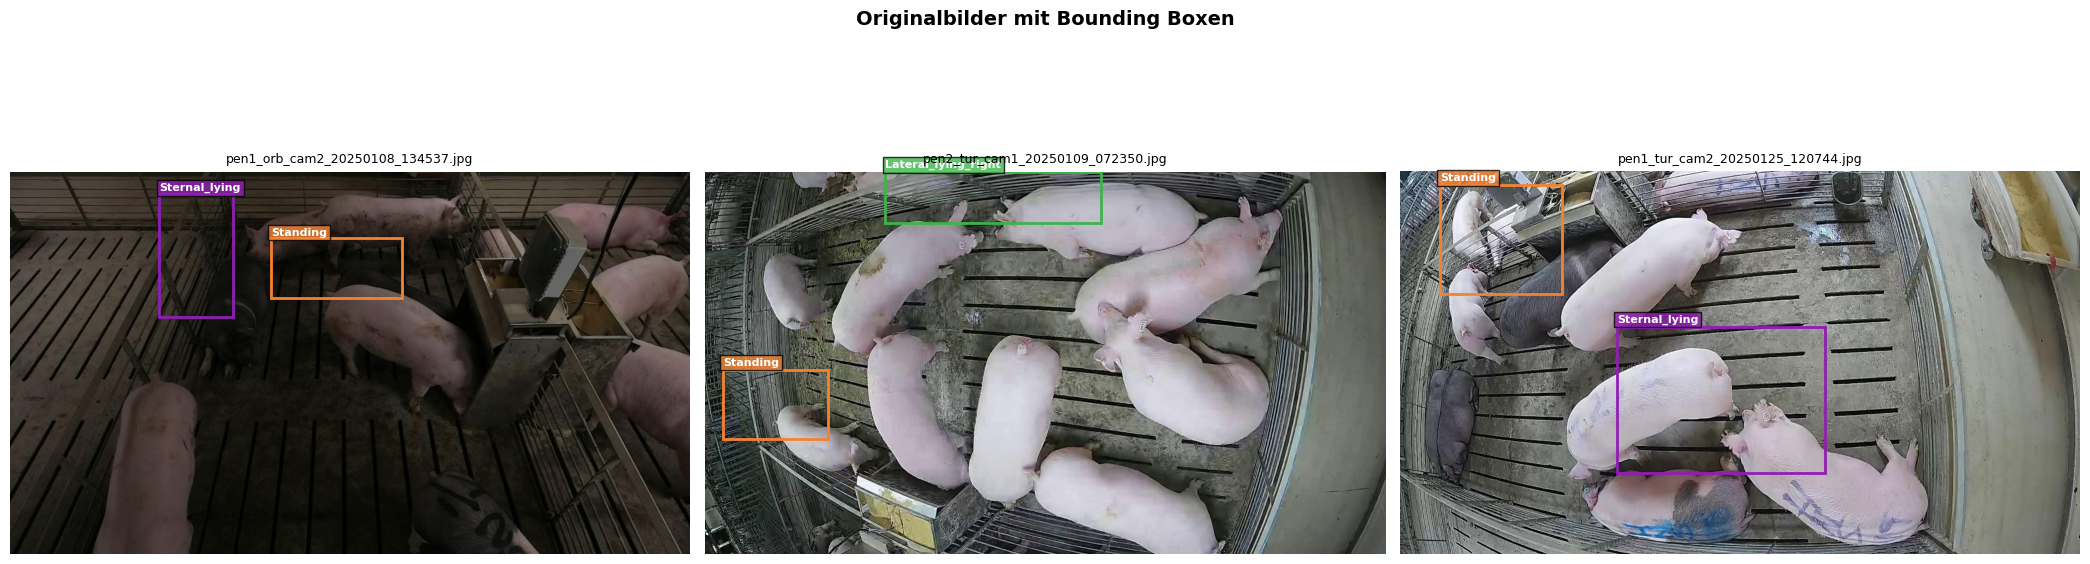

In [34]:
# === BBoxen auf Originalbildern anzeigen ===
COLORS = ['#e6194b', '#3cb44b', '#4363d8', '#f58231', '#911eb4']

sample_images = df.groupby('img_path').filter(lambda x: len(x) >= 2)
unique_imgs = sample_images['img_path'].unique()[:3]

fig, axes = plt.subplots(1, len(unique_imgs), figsize=(7 * len(unique_imgs), 7))
if len(unique_imgs) == 1:
    axes = [axes]

for ax, img_path in zip(axes, unique_imgs):
    img = Image.open(img_path).convert('RGB')
    ax.imshow(np.array(img))

    for _, row in df[df['img_path'] == img_path].iterrows():
        c = int(row['class_id'])
        w = row['xmax'] - row['xmin']
        h = row['ymax'] - row['ymin']
        rect = patches.Rectangle((row['xmin'], row['ymin']), w, h,
                                  linewidth=2, edgecolor=COLORS[c], facecolor='none')
        ax.add_patch(rect)
        ax.text(row['xmin'], row['ymin'] - 8, CLASS_NAMES[c],
                fontsize=8, color='white', fontweight='bold',
                bbox=dict(facecolor=COLORS[c], alpha=0.8, pad=2))
    ax.set_title(os.path.basename(img_path), fontsize=9)
    ax.axis('off')

plt.suptitle("Originalbilder mit Bounding Boxen", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [36]:
# === Dataset: Schwein per BBox ausschneiden ===
class PigCropDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['img_path']).convert('RGB')
        # Schwein per BBox ausschneiden
        crop = img.crop((int(row['xmin']), int(row['ymin']),
                         int(row['xmax']), int(row['ymax'])))
        crop = self.transform(crop)
        label = torch.tensor(int(row['class_id']), dtype=torch.long)
        return crop, label

# Augmentation für Training, einfach für Validierung
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# Stratified Split
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42,
                                     stratify=df['class_id'])

train_loader = DataLoader(PigCropDataset(train_df, train_transform),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(PigCropDataset(val_df, val_transform),
                        batch_size=BATCH_SIZE)

print(f"Training:    {len(train_df)} Crops")
print(f"Validierung: {len(val_df)} Crops")

Training:    400 Crops
Validierung: 100 Crops


In [37]:
# === Modell: ResNet18 mit gefrorenem Backbone ===
model = models.resnet18(weights='DEFAULT')

# Alle Layer einfrieren
for param in model.parameters():
    param.requires_grad = False

# Nur letzten Layer ersetzen und trainieren
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=LEARNING_RATE)

total_params = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parameter gesamt:    {total_params:,}")
print(f"Parameter trainiert: {trainable:,} (nur fc-Layer)")

Parameter gesamt:    11,179,077
Parameter trainiert: 2,565 (nur fc-Layer)


In [38]:
# === Training ===
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(NUM_EPOCHS):
    # --- Training ---
    model.train()
    loss_sum, correct, total = 0.0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * imgs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += imgs.size(0)
    train_losses.append(loss_sum / total)
    train_accs.append(correct / total)

    # --- Validierung ---
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss_sum += loss.item() * imgs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += imgs.size(0)
    val_losses.append(loss_sum / total)
    val_accs.append(correct / total)

    print(f"Epoche {epoch+1:2d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_losses[-1]:.4f}  Acc: {train_accs[-1]:.3f} | "
          f"Val Loss: {val_losses[-1]:.4f}  Acc: {val_accs[-1]:.3f}")

Epoche  1/10 | Train Loss: 1.5795  Acc: 0.393 | Val Loss: 1.4318  Acc: 0.400
Epoche  2/10 | Train Loss: 1.4162  Acc: 0.450 | Val Loss: 1.3439  Acc: 0.460
Epoche  3/10 | Train Loss: 1.2865  Acc: 0.475 | Val Loss: 1.2712  Acc: 0.500
Epoche  4/10 | Train Loss: 1.2386  Acc: 0.515 | Val Loss: 1.2224  Acc: 0.510
Epoche  5/10 | Train Loss: 1.1757  Acc: 0.547 | Val Loss: 1.1923  Acc: 0.560
Epoche  6/10 | Train Loss: 1.1476  Acc: 0.550 | Val Loss: 1.1936  Acc: 0.550
Epoche  7/10 | Train Loss: 1.1525  Acc: 0.573 | Val Loss: 1.1523  Acc: 0.600
Epoche  8/10 | Train Loss: 1.0998  Acc: 0.555 | Val Loss: 1.1519  Acc: 0.580
Epoche  9/10 | Train Loss: 1.0762  Acc: 0.593 | Val Loss: 1.1572  Acc: 0.530
Epoche 10/10 | Train Loss: 1.0678  Acc: 0.580 | Val Loss: 1.1149  Acc: 0.570


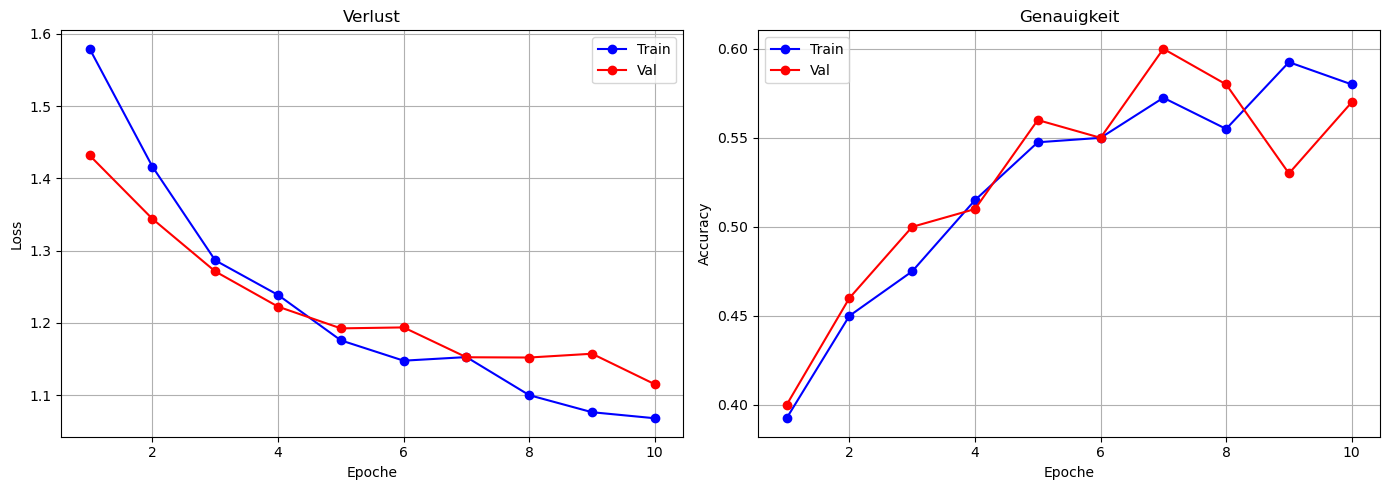

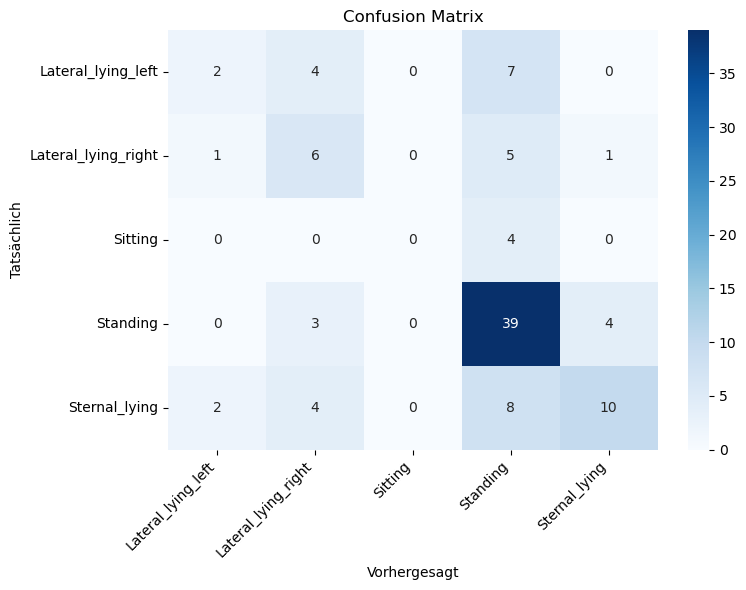

/opt/conda/envs/torch/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/conda/envs/torch/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/conda/envs/torch/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


                     precision    recall  f1-score   support

 Lateral_lying_left      0.400     0.154     0.222        13
Lateral_lying_right      0.353     0.462     0.400        13
            Sitting      0.000     0.000     0.000         4
           Standing      0.619     0.848     0.716        46
      Sternal_lying      0.667     0.417     0.513        24

           accuracy                          0.570       100
          macro avg      0.408     0.376     0.370       100
       weighted avg      0.543     0.570     0.533       100



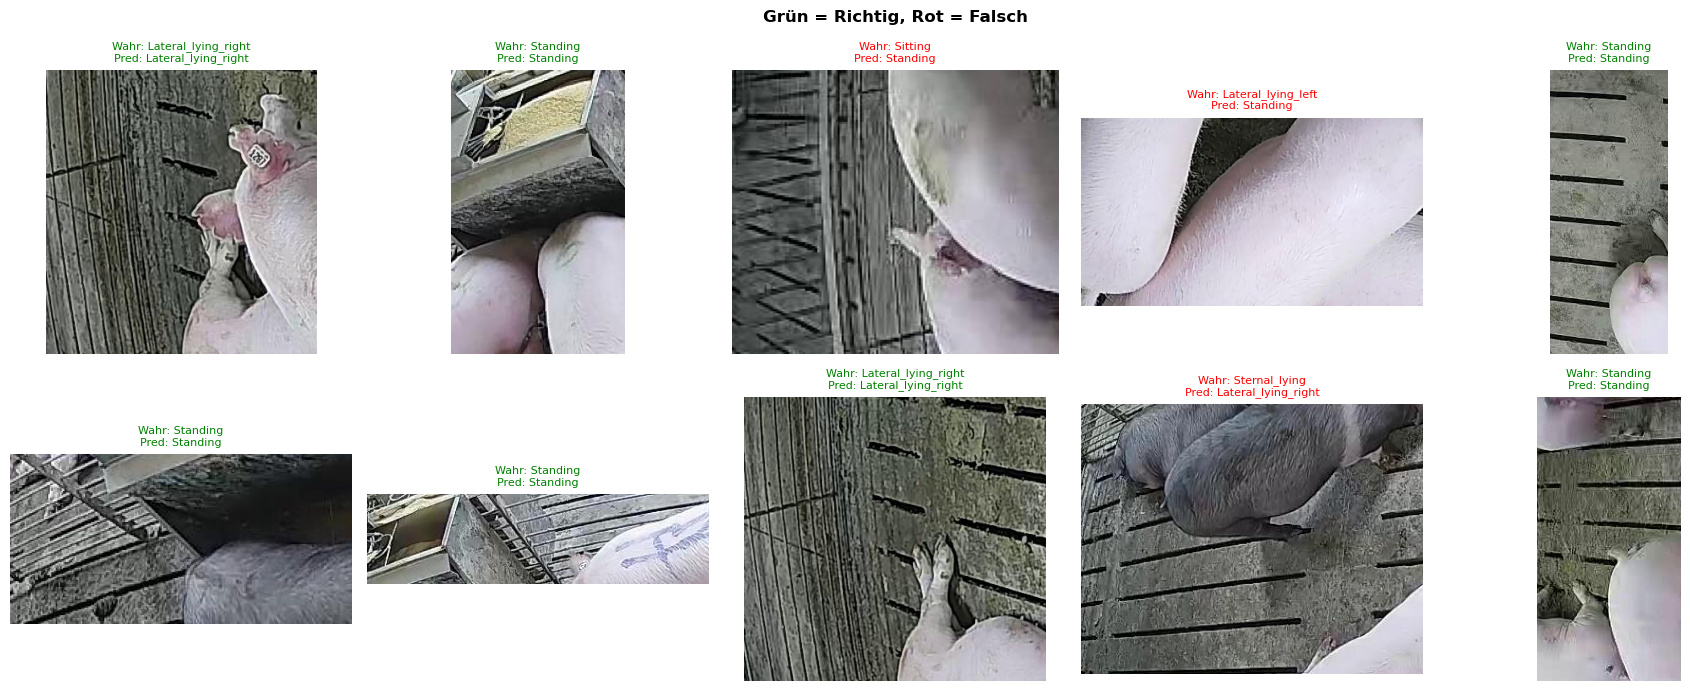

In [39]:
# === Visualisierung ===

# 1) Loss und Accuracy Kurven
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ep = range(1, NUM_EPOCHS + 1)

axes[0].plot(ep, train_losses, 'b-o', label='Train')
axes[0].plot(ep, val_losses, 'r-o', label='Val')
axes[0].set_xlabel('Epoche'); axes[0].set_ylabel('Loss')
axes[0].set_title('Verlust'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(ep, train_accs, 'b-o', label='Train')
axes[1].plot(ep, val_accs, 'r-o', label='Val')
axes[1].set_xlabel('Epoche'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Genauigkeit'); axes[1].legend(); axes[1].grid(True)

plt.tight_layout(); plt.show()

# 2) Confusion Matrix
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        out = model(imgs.to(device))
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Vorhergesagt'); plt.ylabel('Tatsächlich')
plt.title('Confusion Matrix'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

print(classification_report(all_labels, all_preds,
                            target_names=CLASS_NAMES, digits=3))

# 3) Beispiel-Crops mit Vorhersage
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
samples = val_df.sample(10, random_state=0).reset_index(drop=True)

for i, row in samples.iterrows():
    ax = axes[i // 5][i % 5]
    img = Image.open(row['img_path']).convert('RGB')
    crop = img.crop((int(row['xmin']), int(row['ymin']),
                     int(row['xmax']), int(row['ymax'])))
    inp = val_transform(crop).unsqueeze(0).to(device)
    with torch.no_grad():
        pred = model(inp).argmax(1).item()

    ax.imshow(np.array(crop))
    color = 'green' if pred == row['class_id'] else 'red'
    ax.set_title(f"Wahr: {CLASS_NAMES[int(row['class_id'])]}\n"
                 f"Pred: {CLASS_NAMES[pred]}", fontsize=8, color=color)
    ax.axis('off')

plt.suptitle("Grün = Richtig, Rot = Falsch", fontweight='bold')
plt.tight_layout(); plt.show()